# Load the image and flip the intensities

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load coins.png as a grayscale image
img = cv2.imread("coins.png", cv2.IMREAD_GRAYSCALE)

# Flip each pixel: p_new = 255 - p
flipped_img = 255 - img

print("Original image shape:", img.shape)
print("Intensity transformation: p_new = 255 - p")

Original image shape: (203, 248)
Intensity transformation: p_new = 255 - p


# Compute Otsu threshold for the flipped image

In [4]:
hist = np.bincount(flipped_img.ravel(), minlength=256)

total_pixels = flipped_img.size
intensities = np.arange(256)

# Total weighted intensity
total_sum = np.sum(intensities * hist)

weight_background = 0
sum_background = 0

min_variance = np.inf
optimal_threshold = 0

within_class_variances = []

for t in range(256):

    # Update class 0 statistics
    weight_background += hist[t]
    sum_background += t * hist[t]

    if weight_background == 0:
        within_class_variances.append(np.nan)
        continue

    weight_foreground = total_pixels - weight_background

    if weight_foreground == 0:
        within_class_variances.append(np.nan)
        continue

    # Class probabilities
    w0 = weight_background / total_pixels
    w1 = weight_foreground / total_pixels

    # Class means
    mean0 = sum_background / weight_background
    sum_foreground = total_sum - sum_background
    mean1 = sum_foreground / weight_foreground

    # Compute class variances
    pixels0 = np.where(flipped_img <= t, flipped_img, 0)
    pixels1 = np.where(flipped_img > t, flipped_img, 0)

    # Variance using histogram
    class0_values = np.arange(t + 1)
    class0_hist = hist[:t + 1]

    class1_values = np.arange(t + 1, 256)
    class1_hist = hist[t + 1:]

    variance0 = (
        np.sum(class0_hist * (class0_values - mean0) ** 2)
        / weight_background
    )

    variance1 = (
        np.sum(class1_hist * (class1_values - mean1) ** 2)
        / weight_foreground
    )

    # Within-class variance
    intra_variance = w0 * variance0 + w1 * variance1

    within_class_variances.append(intra_variance)

    if intra_variance < min_variance:
        min_variance = intra_variance
        optimal_threshold = t

print("="*25)
print("Otsu Result for Flipped Image")
print("="*25)
print("Optimal Otsu Threshold =", optimal_threshold)
print("Minimum Within-Class Variance =", min_variance)

Otsu Result for Flipped Image
Optimal Otsu Threshold = 129
Minimum Within-Class Variance = 265.1024571148033


# Display original and flipped images

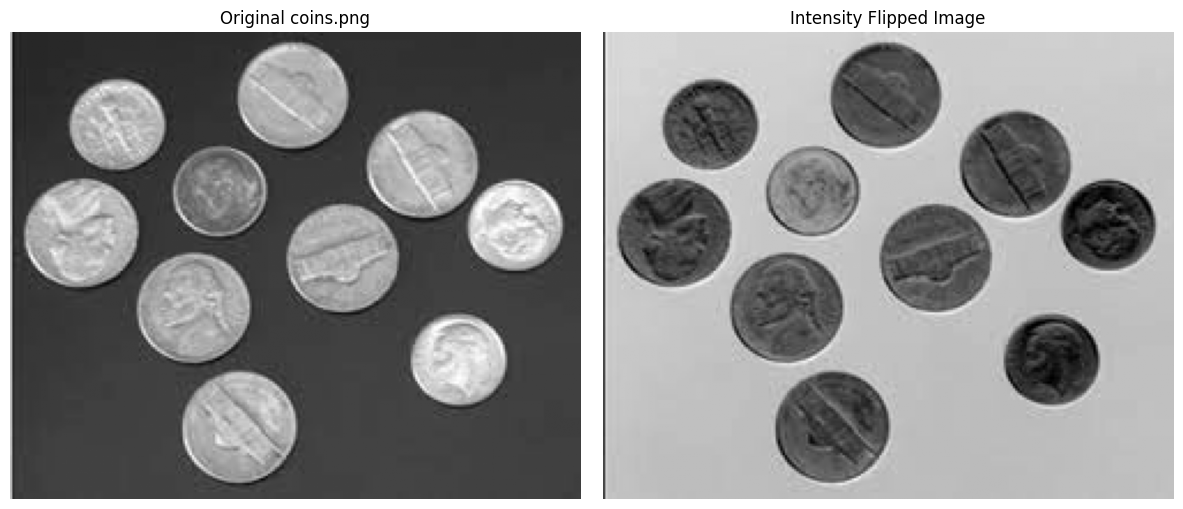

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original coins.png")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flipped_img, cmap="gray")
plt.title("Intensity Flipped Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# Binarize the flipped image

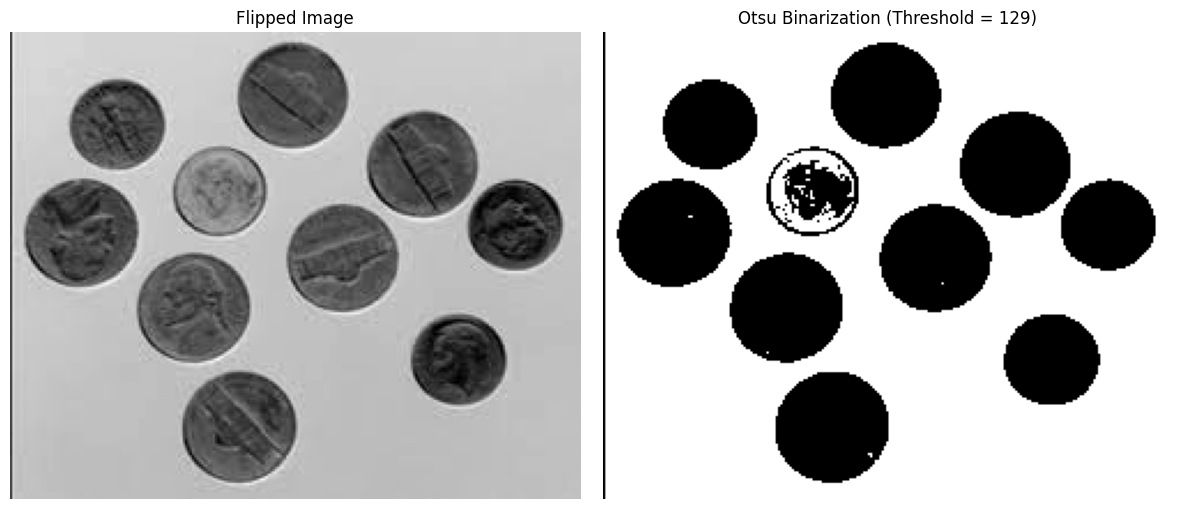

In [6]:
binary_flipped = np.where(
    flipped_img > optimal_threshold,
    255,
    0
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(flipped_img, cmap="gray")
plt.title("Flipped Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary_flipped, cmap="gray")
plt.title(f"Otsu Binarization (Threshold = {optimal_threshold})")
plt.axis("off")

plt.tight_layout()
plt.show()